# EDA: Processed NYC Yellow Taxi Data

This notebook explores `data/processed/yellow_tripdata_2024_processed.parquet`.


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

# PROJECT_ROOT = Path.cwd()
# if not (PROJECT_ROOT / 'data' / 'processed').exists():
#     PROJECT_ROOT = PROJECT_ROOT.parent.parent

DATA_PATH = "./data/processed/yellow_tripdata_2025-11.parquet"

## Load Data

In [ ]:
# df = pd.read_parquet(DATA_PATH)
# print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
# df.head()


In [6]:
import glob

In [7]:
data_dir = Path('../../data/processed') 

print(f"Looking in: {data_dir.absolute()}")
print(f"Exists? {data_dir.exists()}")

if data_dir.exists():
    files = sorted(glob.glob(str(data_dir / 'yellow_tripdata_*.parquet')))
    
    # Load all
    dfs = [pd.read_parquet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)
    
    print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
    df.head()
else:
    print("Check raw data:")
    raw_dir = Path('../../data/raw')
    print(f"Raw data exists? {raw_dir.exists()}")
    
    if raw_dir.exists():
        raw_files = list(raw_dir.glob('*.parquet'))
        print(f"Raw files: {len(raw_files)}")

Looking in: /Users/ellieryus/Documents/GitHub/nyc-mobility-analysis/notebooks/exploratory/../../data/processed
Exists? True
Shape: 69,222,440 rows x 29 columns


## Dataset Overview

In [8]:
df.head()

,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_seconds,vehicle_type,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_dayofweek,pickup_weekday,time_of_day,cbd_congestion_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,1188.0,yellow,2024,1,1,0,0,True,night,NaN
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,396.0,yellow,2024,1,1,0,0,True,night,NaN
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,1075.0,yellow,2024,1,1,0,0,True,night,NaN
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0,498.0,yellow,2024,1,1,0,0,True,night,NaN
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0,366.0,yellow,2024,1,1,0,0,True,night,NaN


In [9]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=True),
})
overview.sort_values(['missing_pct', 'n_unique'], ascending=[False, False]).head(20)


,dtype,missing_count,missing_pct,n_unique
cbd_congestion_fee,float64,36461786,52.67,4
pickup_datetime,datetime64[us],0,0.00,36343297
dropoff_datetime,datetime64[us],0,0.00,36314863
total_amount,float64,0,0.00,36492
trip_duration_seconds,float64,0,0.00,26486
fare_amount,float64,0,0.00,12181
tip_amount,float64,0,0.00,8594
trip_distance,float64,0,0.00,8079
tolls_amount,float64,0,0.00,4049
pickup_location_id,int32,0,0.00,263


In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
VendorID,69222440.0,1.766502,0.423057,1.00,1.0,1.00,2.00,2.00,2.00,2.00,2.00,2.00
passenger_count,69222440.0,1.313687,0.776045,0.00,1.0,1.00,1.00,1.00,1.00,3.00,5.00,8.00
trip_distance,69222440.0,3.381794,4.528995,0.00,0.0,0.47,1.00,1.70,3.28,15.14,20.11,99.86
RatecodeID,69222440.0,2.718396,12.519476,1.00,1.0,1.00,1.00,1.00,1.00,2.00,99.00,99.00
pickup_location_id,69222440.0,165.035499,63.321544,1.00,24.0,48.00,132.00,162.00,233.00,249.00,263.00,265.00
dropoff_location_id,69222440.0,164.505662,69.260922,1.00,12.0,43.00,114.00,162.00,234.00,259.00,263.00,265.00
payment_type,69222440.0,1.188885,0.498164,1.00,1.0,1.00,1.00,1.00,1.00,2.00,4.00,5.00
fare_amount,69222440.0,19.826258,18.851944,0.00,4.4,5.80,9.30,13.50,21.90,70.00,83.69,999.00
extra,69222440.0,1.589841,1.872971,-17.39,0.0,0.00,0.00,1.00,2.50,5.00,7.50,23.69
mta_tax,69222440.0,0.492808,0.633055,-0.50,0.0,0.50,0.50,0.50,0.50,0.50,0.50,5243.38


## Quality Checks

In [11]:
checks = {
    'negative_trip_distance': (df['trip_distance'] < 0).sum(),
    'negative_fare_amount': (df['fare_amount'] < 0).sum(),
    'negative_total_amount': (df['total_amount'] < 0).sum(),
    'negative_duration': (df['trip_duration_seconds'] < 0).sum(),
    'pickup_after_dropoff': (df['pickup_datetime'] > df['dropoff_datetime']).sum(),
}
pd.Series(checks).to_frame('count')


,count
negative_trip_distance,0
negative_fare_amount,0
negative_total_amount,7115
negative_duration,0
pickup_after_dropoff,0


## Temporal Patterns

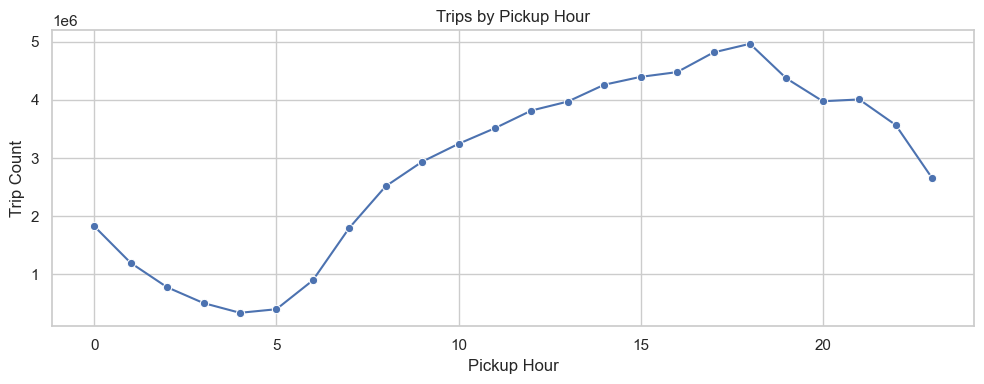

In [12]:
hourly_trips = df.groupby('pickup_hour').size().rename('trip_count').reset_index()
plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_trips, x='pickup_hour', y='trip_count', marker='o')
plt.title('Trips by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Trip Count')
plt.tight_layout()
plt.show()


/var/folders/sw/mjx9sw_n3h98qfs53h96_gl40000gn/T/ipykernel_97405/1334139563.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_trips, x='pickup_dayofweek', y='trip_count', palette='Blues_d')


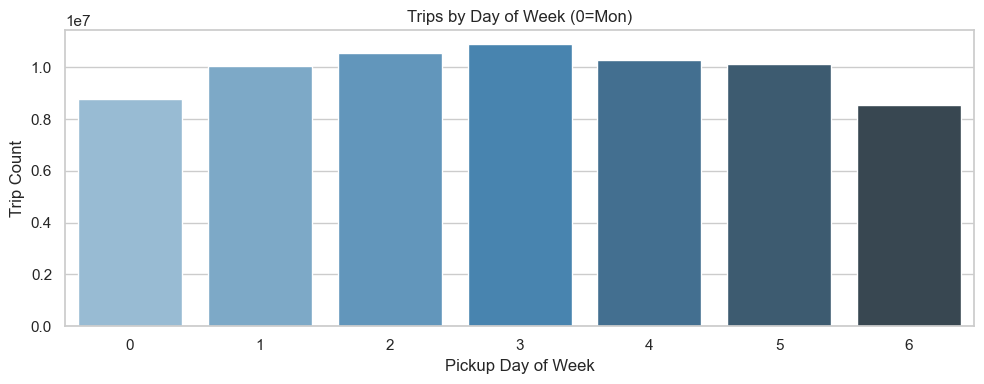

In [13]:
dow_trips = (
    df.groupby('pickup_dayofweek')
    .size()
    .rename('trip_count')
    .reset_index()
    .sort_values('pickup_dayofweek')
)
plt.figure(figsize=(10, 4))
sns.barplot(data=dow_trips, x='pickup_dayofweek', y='trip_count', palette='Blues_d')
plt.title('Trips by Day of Week (0=Mon)')
plt.xlabel('Pickup Day of Week')
plt.ylabel('Trip Count')
plt.tight_layout()
plt.show()


## Distribution Analysis

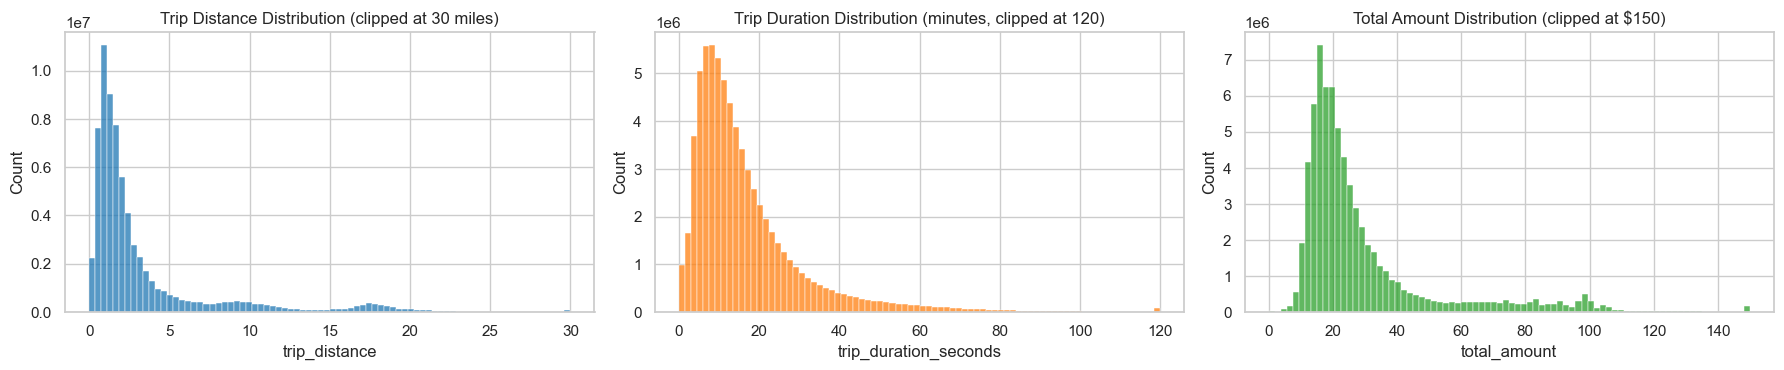

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df['trip_distance'].clip(upper=30), bins=80, ax=axes[0], color='#1f77b4')
axes[0].set_title('Trip Distance Distribution (clipped at 30 miles)')

sns.histplot((df['trip_duration_seconds'] / 60).clip(upper=120), bins=80, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Trip Duration Distribution (minutes, clipped at 120)')

sns.histplot(df['total_amount'].clip(lower=0, upper=150), bins=80, ax=axes[2], color='#2ca02c')
axes[2].set_title('Total Amount Distribution (clipped at $150)')

for ax in axes:
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## Payment and Time-of-Day Mix

In [15]:
payment_mix = (
    df['payment_type']
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2)
    .rename('pct')
    .to_frame()
)
payment_mix


,pct
payment_type,
1,84.46
2,13.58
4,1.40
3,0.56
5,0.00


/var/folders/sw/mjx9sw_n3h98qfs53h96_gl40000gn/T/ipykernel_97405/2246669934.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_mix, x='time_of_day', y='pct', palette='viridis')


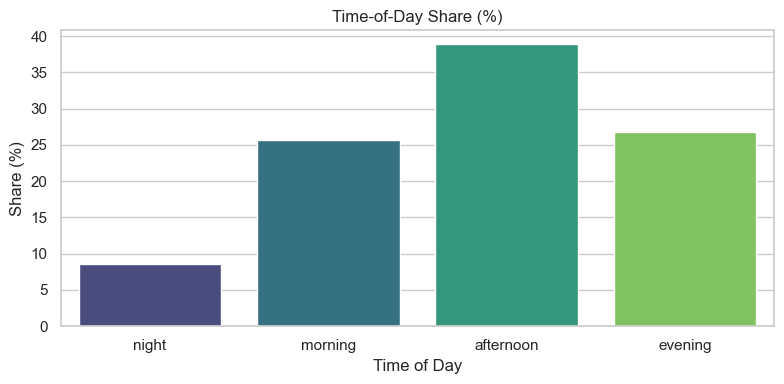

In [16]:
time_mix = (
    df['time_of_day']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename('pct')
    .reset_index()
    .rename(columns={'index': 'time_of_day'})
)
plt.figure(figsize=(8, 4))
sns.barplot(data=time_mix, x='time_of_day', y='pct', palette='viridis')
plt.title('Time-of-Day Share (%)')
plt.xlabel('Time of Day')
plt.ylabel('Share (%)')
plt.tight_layout()
plt.show()


## Top Zones (By ID)

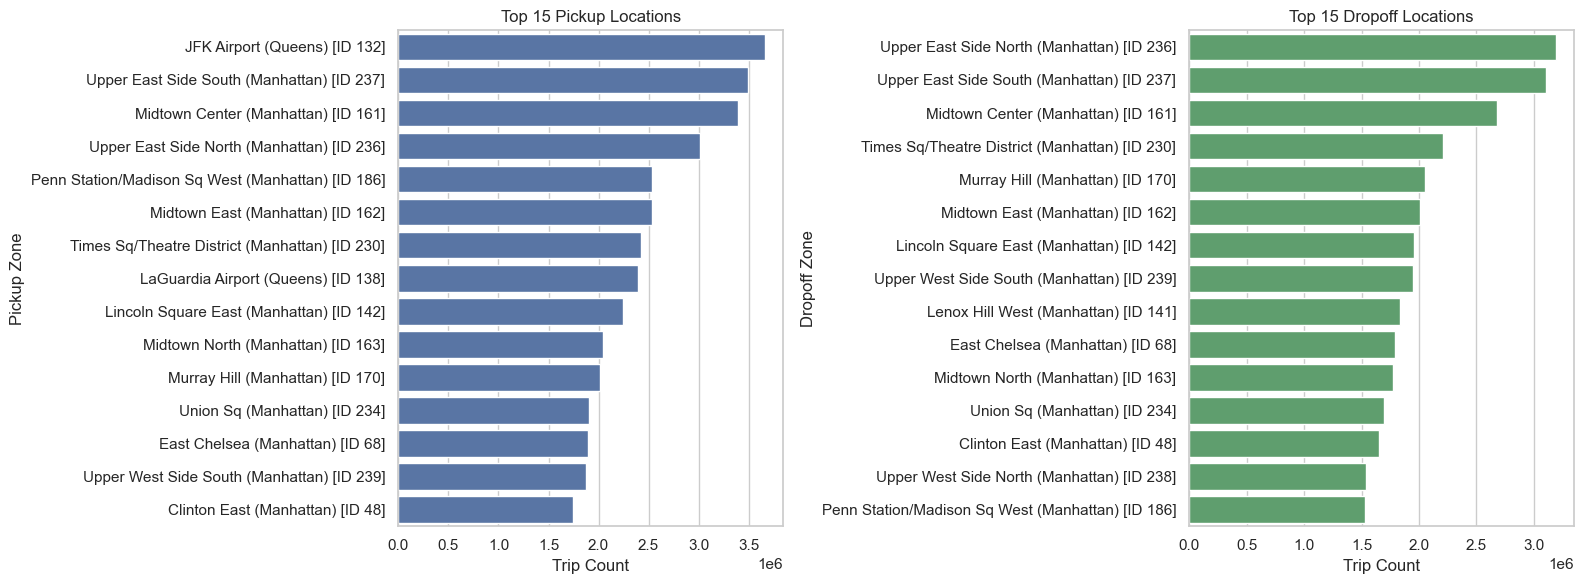

In [18]:
# Adjust path if your notebook is under notebooks/ (e.g., "../../data/external/taxi_zone_lookup.csv")
zones = pd.read_csv("../../data/external/taxi_zone_lookup.csv")[["LocationID", "Zone", "Borough"]]
zones["label"] = zones["Zone"] + " (" + zones["Borough"] + ")"
id_to_label = zones.set_index("LocationID")["label"]

top_pickup = df["pickup_location_id"].value_counts().head(15)
top_dropoff = df["dropoff_location_id"].value_counts().head(15)

pickup_plot = top_pickup.rename_axis("LocationID").reset_index(name="Trip Count")
dropoff_plot = top_dropoff.rename_axis("LocationID").reset_index(name="Trip Count")

pickup_plot["Location"] = (
    pickup_plot["LocationID"].map(id_to_label).fillna("Unknown")
    + " [ID "
    + pickup_plot["LocationID"].astype(str)
    + "]"
)
dropoff_plot["Location"] = (
    dropoff_plot["LocationID"].map(id_to_label).fillna("Unknown")
    + " [ID "
    + dropoff_plot["LocationID"].astype(str)
    + "]"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=pickup_plot, x="Trip Count", y="Location", ax=axes[0], color="#4c72b0")
axes[0].set_title("Top 15 Pickup Locations")
axes[0].set_xlabel("Trip Count")
axes[0].set_ylabel("Pickup Zone")

sns.barplot(data=dropoff_plot, x="Trip Count", y="Location", ax=axes[1], color="#55a868")
axes[1].set_title("Top 15 Dropoff Locations")
axes[1].set_xlabel("Trip Count")
axes[1].set_ylabel("Dropoff Zone")

plt.tight_layout()
plt.show()

## Correlations

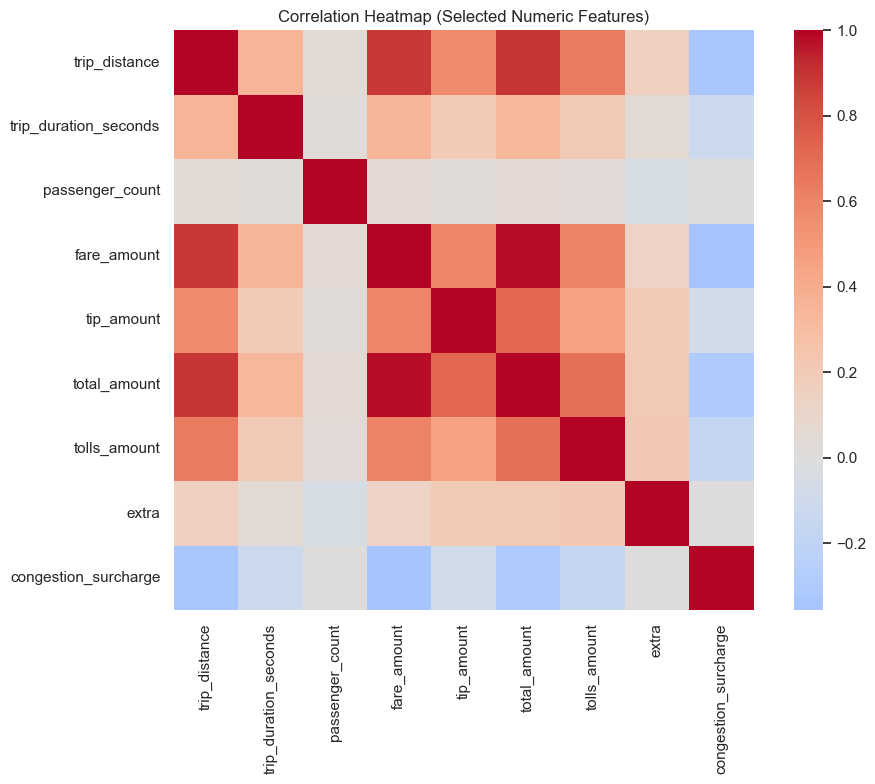

,trip_distance,trip_duration_seconds,passenger_count,fare_amount,tip_amount,total_amount,tolls_amount,extra,congestion_surcharge
trip_distance,1.000000,0.356127,0.042353,0.887245,0.564542,0.889268,0.639485,0.161248,-0.334651
trip_duration_seconds,0.356127,1.000000,0.026240,0.347075,0.203094,0.339057,0.211106,0.046418,-0.117691
passenger_count,0.042353,0.026240,1.000000,0.059481,0.025653,0.057314,0.038707,-0.054473,0.012998
fare_amount,0.887245,0.347075,0.059481,1.000000,0.594073,0.977652,0.606757,0.129500,-0.356730
tip_amount,0.564542,0.203094,0.025653,0.594073,1.000000,0.720031,0.459422,0.200157,-0.079786
total_amount,0.889268,0.339057,0.057314,0.977652,0.720031,1.000000,0.685662,0.217133,-0.294411
tolls_amount,0.639485,0.211106,0.038707,0.606757,0.459422,0.685662,1.000000,0.224259,-0.169124
extra,0.161248,0.046418,-0.054473,0.129500,0.200157,0.217133,0.224259,1.000000,0.009270
congestion_surcharge,-0.334651,-0.117691,0.012998,-0.356730,-0.079786,-0.294411,-0.169124,0.009270,1.000000


In [19]:
corr_cols = [
    'trip_distance',
    'trip_duration_seconds',
    'passenger_count',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'tolls_amount',
    'extra',
    'congestion_surcharge',
]

corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap (Selected Numeric Features)')
plt.tight_layout()
plt.show()

corr


## Key Takeaways

- Review demand concentration by hour/day to guide feature engineering for forecasting tasks.
- Validate outliers in distance, duration, and fare before modeling.
- Consider joining zone metadata (`data/external/taxi_zone_lookup.csv`) for richer spatial insights.
